<h1>Інтелектуальний аналіз даних 2026</h1>

<h2> Lab 1: Базові алгоритми класифікації у Scikit-learn</h2>

**Мета дослідження:** ознайомитися з базовим workflow задачі класифікації: від вибору та аналізу даних до навчання, налаштування, порівняння та оцінювання моделей машинного навчання з використанням бібліотеки Scikit-learn.

Використано [**PhiUSIIL Phishing URL Dataset**](https://archive.ics.uci.edu/dataset/967/phiusil-phishing-url-dataset).; цільова змінна `label` набуває значень 0 (фішинг) та 1 (легітимний URL).

In [77]:
# Обробка даних і візуалізація
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Попередня обробка
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Розподіл даних і оптимізація гіперпараметрів
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# Класифікатори
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Оцінювання моделей
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from IPython.display import display
from sklearn.base import clone

# Єдиний стиль графіків і таблиць.
sns.set_theme(style="ticks", context="notebook", font="DejaVu Sans")
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, "font.size": 10,
    "axes.titlesize": 11, "axes.labelsize": 10, "axes.titlepad": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#e2e7ec", "grid.linewidth": 0.6,
    "legend.frameon": False, "figure.facecolor": "white"
})
RANDOM_STATE = 69
class_names = ["Фішинг", "Легітимний"]
class_colors = ["#b65b3b", "#326789"]


def show_table(data, caption, decimals=4):
    """Стандартне відображення таблиці pandas."""
    print(caption)
    display(data.round(decimals))


## 1. Завантаження та первинний аналіз

In [78]:
# Завантаження вихідних даних
data_paths = [
    Path("data/PhiUSIIL_Phishing_URL_Dataset.csv"),
    Path("../data/PhiUSIIL_Phishing_URL_Dataset.csv"),
]
data_path = next((path for path in data_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("CSV file was not found in the data folder.")

df = pd.read_csv(data_path, encoding="utf-8-sig")

# Структура датасета
print(f"Розмір датасета: {df.shape[0]} рядків × {df.shape[1]} колонок")
column_info = pd.DataFrame({
    "Колонка": df.columns,
    "Тип даних": df.dtypes.astype(str).values,
})
show_table(column_info, "Таблиця 1. Структура вихідних даних")

# Визначення ознак і цільової змінної
target_column = "label"
feature_columns = [
    "URLLength",
    "TLD",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "CharContinuationRate",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS",
]


X = df[feature_columns].copy()
y = df[target_column].copy()
print("Цільова змінна:", target_column)
print("Обрані ознаки:", feature_columns)
show_table(df[feature_columns + [target_column]].head(), "Таблиця 2. Приклад спостережень (обрані ознаки)", decimals=3)
show_table(X.describe().T.reset_index().rename(columns={"index": "Ознака"}),
           "Таблиця 3. Описова статистика числових ознак", decimals=3)

Розмір датасета: 235795 рядків × 56 колонок
Таблиця 1. Структура вихідних даних


,Колонка,Тип даних
0,FILENAME,object
1,URL,object
2,URLLength,int64
3,Domain,object
4,DomainLength,int64
5,IsDomainIP,int64
6,TLD,object
7,URLSimilarityIndex,float64
8,CharContinuationRate,float64
9,TLDLegitimateProb,float64


Цільова змінна: label
Обрані ознаки: ['URLLength', 'TLD', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain', 'CharContinuationRate', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS']
Таблиця 2. Приклад спостережень (обрані ознаки)


,URLLength,TLD,DomainLength,IsDomainIP,TLDLength,NoOfSubDomain,CharContinuationRate,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,...,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,label
0,31,com,24,0,3,1,1.000,0,0,0.0,...,0.581,0,0.0,0,0,0,1,0.032,1,1
1,23,de,16,0,2,1,0.667,0,0,0.0,...,0.391,0,0.0,0,0,0,2,0.087,1,1
2,29,uk,22,0,2,2,0.867,0,0,0.0,...,0.517,0,0.0,0,0,0,2,0.069,1,1
3,26,com,19,0,3,1,1.000,0,0,0.0,...,0.500,0,0.0,0,0,0,1,0.038,1,1
4,33,org,26,0,3,1,1.000,0,0,0.0,...,0.606,0,0.0,0,0,0,1,0.030,1,1


Таблиця 3. Описова статистика числових ознак


,Ознака,count,mean,std,min,25%,50%,75%,max
0,URLLength,235795.0,34.573,41.314,13.0,23.000,27.000,34.000,6097.000
1,DomainLength,235795.0,21.470,9.151,4.0,16.000,20.000,24.000,110.000
2,IsDomainIP,235795.0,0.003,0.052,0.0,0.000,0.000,0.000,1.000
3,TLDLength,235795.0,2.764,0.600,2.0,2.000,3.000,3.000,13.000
4,NoOfSubDomain,235795.0,1.165,0.601,0.0,1.000,1.000,1.000,10.000
5,CharContinuationRate,235795.0,0.846,0.217,0.0,0.680,1.000,1.000,1.000
6,HasObfuscation,235795.0,0.002,0.045,0.0,0.000,0.000,0.000,1.000
7,NoOfObfuscatedChar,235795.0,0.025,1.876,0.0,0.000,0.000,0.000,447.000
8,ObfuscationRatio,235795.0,0.000,0.004,0.0,0.000,0.000,0.000,0.348
9,NoOfLettersInURL,235795.0,19.429,29.090,0.0,10.000,14.000,20.000,5191.000


Набір характеризує довжину та структуру URL, доменну зону, склад символів, обфускацію й використання HTTPS. Службову колонку `FILENAME` виключено; сирі `URL` та `Domain` потребують окремої обробки тексту Відбір здійснено за змістом ознак; оптимальність набору не перевірялася.

Таблиця 4. Розподіл спостережень за класами


,Клас,Кількість,"Частка, %"
0,Фішинг,100945,42.81
1,Легітимний,134850,57.19


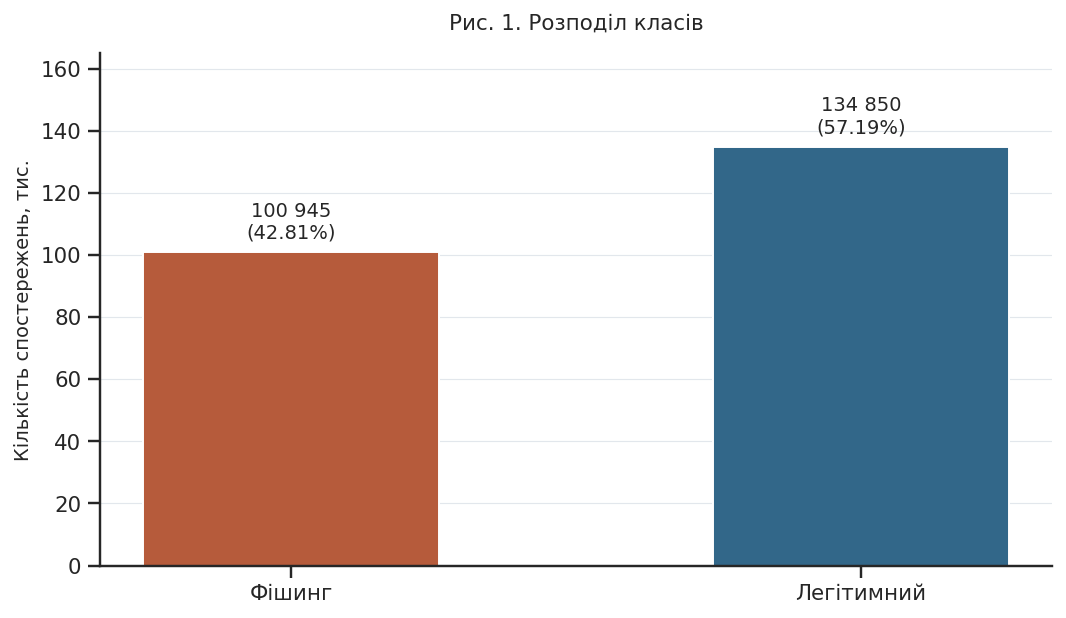

In [79]:
class_counts = y.value_counts().sort_index()
class_table = pd.DataFrame({"Клас": class_names, "Кількість": class_counts.values,
    "Частка, %": class_counts.values / len(y) * 100})
show_table(class_table, "Таблиця 4. Розподіл спостережень за класами", decimals=2)
fig, ax = plt.subplots(figsize=(7.5, 4.3), layout="constrained")
bars = ax.bar(class_names, class_counts.values / 1000, color=class_colors, width=0.52)
for bar, count in zip(bars, class_counts.values):
    ax.annotate(f"{count:,}".replace(",", " ") + f"\n({count / len(y):.2%})",
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 7), textcoords="offset points", ha="center", fontsize=10)
ax.set(title="Рис. 1. Розподіл класів", ylabel="Кількість спостережень, тис.", ylim=(0, 165))
ax.yaxis.grid(True)
ax.set_axisbelow(True)
plt.show()

Датасет містить 235 795 спостережень і 56 колонок. Частки фішингових та легітимних URL становлять 42,81% і 57,19% відповідно.

## 2. Перевірка та попередня обробка

In [80]:
quality_table = pd.DataFrame({
    "Показник": ["Пропущені значення (усі колонки)", "Повні дублікати", "Повторні URL"],
    "Кількість": [df.isna().sum().sum(), df.duplicated().sum(), df["URL"].duplicated().sum()]
})
show_table(quality_table, "Таблиця 5. Контроль якості даних")
numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = ["TLD"]

Таблиця 5. Контроль якості даних


,Показник,Кількість
0,Пропущені значення (усі колонки),0
1,Повні дублікати,0
2,Повторні URL,425


Пропущені значення та повні дублікати відсутні. Перед формуванням підвибірки усунено 425 повторних URL зі збереженням першого запису кожної адреси. Первинний аналіз та EDA виконано для початкових даних. Категоріальну ознаку `TLD` закодовано методом one-hot. Масштабування числових ознак застосовано лише для kNN і SVM.

## 3. Візуалізація та дослідницький аналіз даних

Розглянуто шість числових ознак. Для гістограм відображено спостереження до 99-го процентиля кожної ознаки; boxplot розраховано за повними даними.

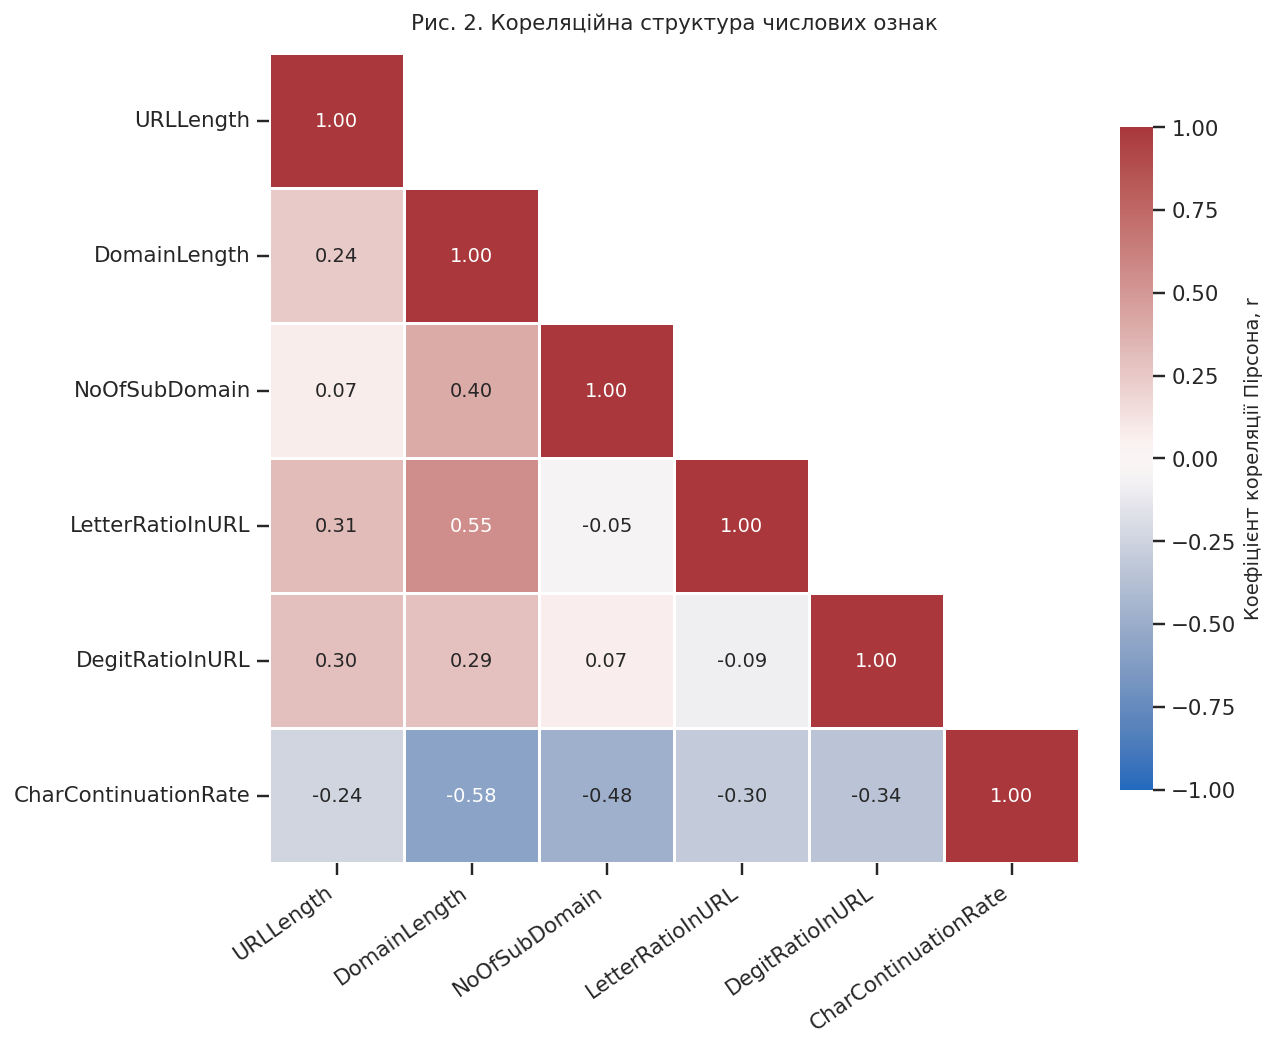

In [81]:
eda_features = ["URLLength", "DomainLength", "NoOfSubDomain", "LetterRatioInURL", "DegitRatioInURL", "CharContinuationRate"]
eda_corr = X[eda_features].corr()
fig, ax = plt.subplots(figsize=(9, 7.5), layout="constrained")
sns.heatmap(eda_corr, mask=np.triu(np.ones_like(eda_corr, dtype=bool), k=1),
            annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.7, annot_kws={"fontsize": 10},
            xticklabels=eda_features, yticklabels=eda_features,
            cbar_kws={"label": "Коефіцієнт кореляції Пірсона, r", "shrink": 0.8}, ax=ax)
ax.set_title("Рис. 2. Кореляційна структура числових ознак")
ax.tick_params(axis="x", rotation=35)
for label in ax.get_xticklabels():
    label.set_ha("right")
ax.tick_params(axis="y", rotation=0)
plt.show()

Коефіцієнт Пірсона характеризує напрям і силу лінійного зв’язку між ознаками. Додатна кореляція довжини домену та кількості піддоменів узгоджується зі структурою URL. Кореляційні залежності не встановлюють причинності та не є достатньою підставою для вилучення ознак.

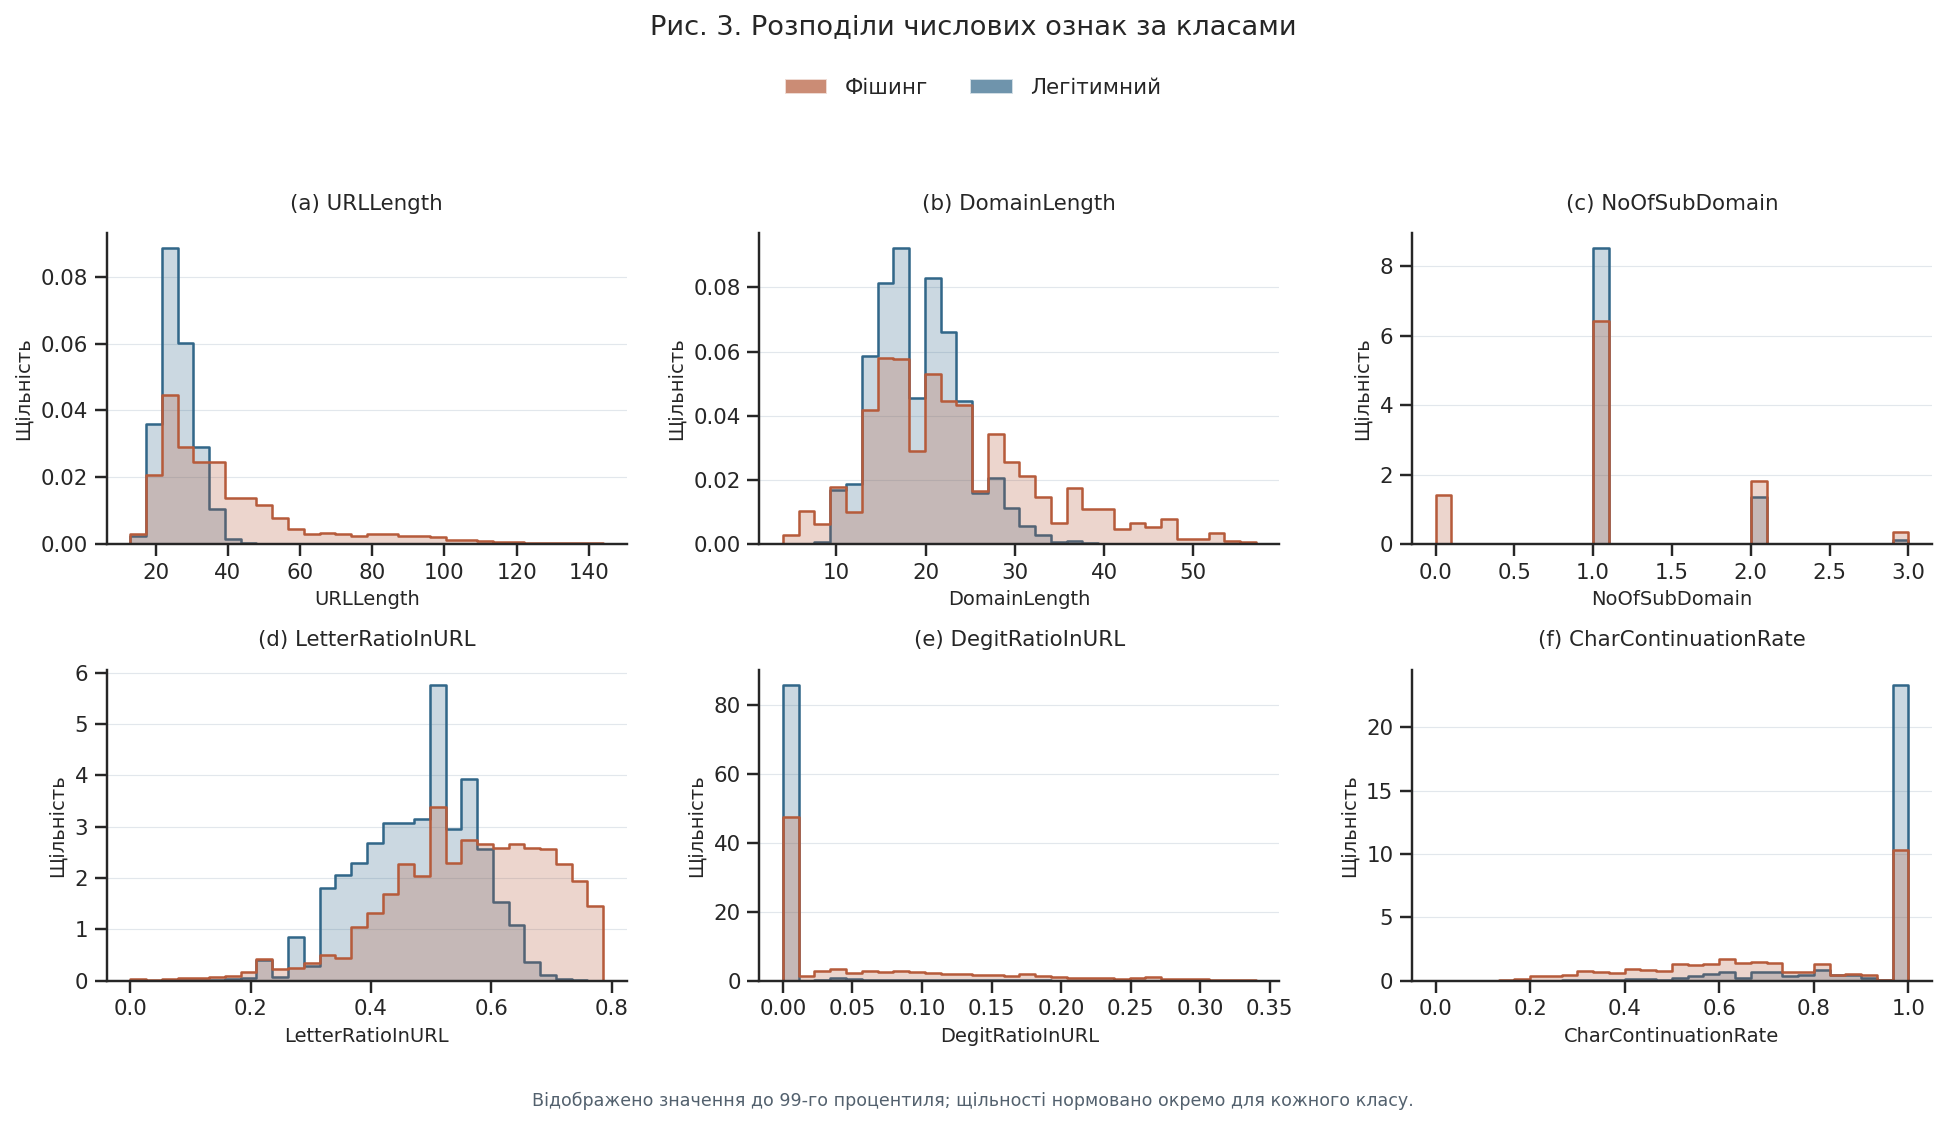

In [82]:
eda = df[eda_features + [target_column]].copy()
eda["Клас"] = eda[target_column].map(dict(enumerate(class_names)))
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for index, (feature, ax) in enumerate(zip(eda_features, axes.flat)):
    visible = eda.loc[eda[feature] <= eda[feature].quantile(0.99)]
    sns.histplot(data=visible, x=feature, hue="Клас", hue_order=class_names,
                 palette=class_colors, bins=30, element="step", stat="density",
                 common_norm=False, alpha=0.25, linewidth=1.3, legend=False, ax=ax)
    ax.set(title=f"({chr(97 + index)}) {feature}",
           xlabel=feature, ylabel="Щільність")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
fig.suptitle("Рис. 3. Розподіли числових ознак за класами", fontsize=14, y=0.99)
fig.legend(handles=[Patch(facecolor=color, label=name, alpha=0.7) for name, color in zip(class_names, class_colors)],
           loc="upper center", bbox_to_anchor=(0.5, 0.95), ncol=2)
fig.text(0.5, 0.015, "Відображено значення до 99-го процентиля; щільності нормовано окремо для кожного класу.", ha="center", fontsize=9, color="#53616e")
fig.tight_layout(rect=(0, 0.05, 1, 0.89))
plt.show()

Розподіли довжин URL і доменів є асиметричними. Для частки цифр спостерігається концентрація значень біля нуля. Перекриття розподілів класів указує на обмеженість класифікації за окремою ознакою. Незалежне нормування щільностей забезпечує порівнянність класів різного обсягу.

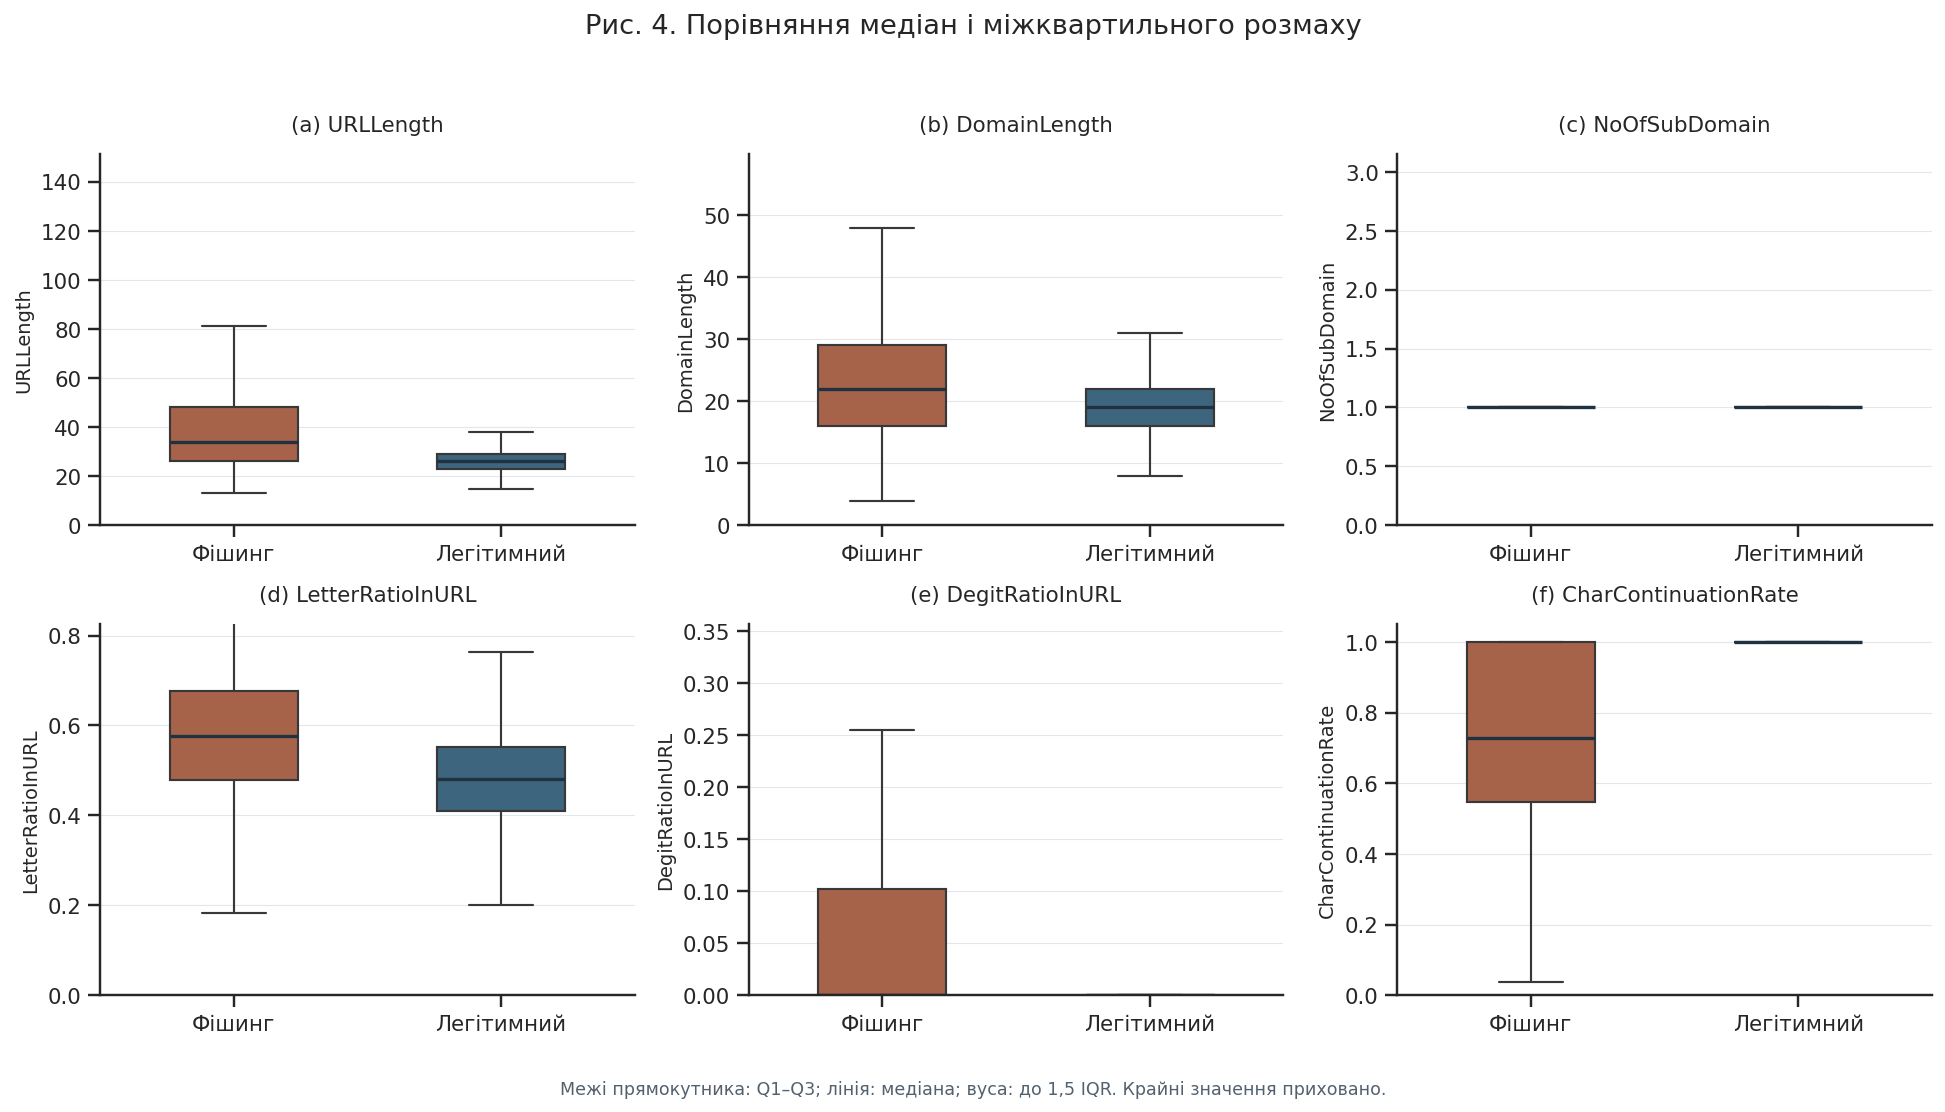

Таблиця 6. Медіани ознак за класами


,Клас,URLLength,DomainLength,NoOfSubDomain,LetterRatioInURL,DegitRatioInURL,CharContinuationRate,IsHTTPS
0,Фішинг,34.0,22.0,1.0,0.577,0.0,0.727,0.0
1,Легітимний,26.0,19.0,1.0,0.480,0.0,1.000,1.0


In [83]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for index, (feature, ax) in enumerate(zip(eda_features, axes.flat)):
    sns.boxplot(data=eda, x="Клас", y=feature, hue="Клас", order=class_names,
                hue_order=class_names, palette=class_colors, legend=False,
                showfliers=False, width=0.48, linewidth=1.1,
                medianprops={"color": "#20313f", "linewidth": 1.7}, ax=ax)
    ax.set_ylim(0, max(eda[feature].quantile(0.99) * 1.05, 0.01))
    ax.set(title=f"({chr(97 + index)}) {feature}", xlabel="", ylabel=feature)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
fig.suptitle("Рис. 4. Порівняння медіан і міжквартильного розмаху", fontsize=14)
fig.text(0.5, 0.015, "Межі прямокутника: Q1–Q3; лінія: медіана; вуса: до 1,5 IQR. Крайні значення приховано.", ha="center", fontsize=9, color="#53616e")
fig.tight_layout(rect=(0, 0.05, 1, 0.95))
plt.show()
median_table = df.groupby("label")[eda_features + ["IsHTTPS"]].median()
median_table.index = class_names
show_table(median_table.reset_index(names="Клас"), "Таблиця 6. Медіани ознак за класами", decimals=3)

## 4. Формування навчальної та тестової вибірок

In [84]:
# Формування спільної стратифікованої підвибірки для всіх моделей.
SAMPLE_SIZE = 10_000
unique_df = df.drop_duplicates(subset="URL").copy()
work_df, _ = train_test_split(unique_df, train_size=SAMPLE_SIZE, stratify=unique_df[target_column], random_state=RANDOM_STATE)
X_work = work_df[feature_columns]
y_work = work_df[target_column]
X_train, X_test, y_train, y_test = train_test_split(
    X_work, y_work, test_size=0.2, stratify=y_work, random_state=RANDOM_STATE
)
assert not set(work_df.loc[X_train.index, "URL"]) & set(work_df.loc[X_test.index, "URL"])
show_table(pd.DataFrame({"Вибірка": ["Навчальна", "Тестова"],
    "Рядків": [len(y_train), len(y_test)],
    "Фішинг": [(y_train == 0).sum(), (y_test == 0).sum()],
    "Легітимні": [(y_train == 1).sum(), (y_test == 1).sum()]}), "Таблиця 7. Склад навчальної та тестової вибірок")

scaled_preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])
tree_preprocessor = ColumnTransformer([
    ("numeric", "passthrough", numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

Таблиця 7. Склад навчальної та тестової вибірок


,Вибірка,Рядків,Фішинг,Легітимні
0,Навчальна,8000,3417,4583
1,Тестова,2000,854,1146


 Навчальна та тестова вибірки містять 8000 і 2000 спостережень відповідно зі збереженням часток класів. Для kNN і SVM застосовано StandardScaler. Параметри перетворень оцінюються лише на навчальній частині кожного розподілу.

## 5. Навчання та оптимізація гіперпараметрів

Критерієм вибору параметрів є середній macro F1 за трикратною стратифікованою крос-валідацією навчальної вибірки. Для kNN оптимізовано кількість сусідів; для SVM із RBF-ядром — параметри `C` та `gamma`, що визначають штраф за помилки та масштаб впливу спостережень.

In [85]:
knn_search = GridSearchCV(
    Pipeline([("preprocessor", clone(scaled_preprocessor)), ("model", KNeighborsClassifier())]),
    {"model__n_neighbors": [3, 5, 7, 11, 15]},
    scoring="f1_macro", cv=cv, n_jobs=1
)
svm_search = GridSearchCV(
    Pipeline([("preprocessor", clone(scaled_preprocessor)), ("model", SVC(kernel="rbf"))]),
    {"model__C": [0.1, 1, 10], "model__gamma": [0.001, 0.01, 0.1]},
    scoring="f1_macro", cv=cv, n_jobs=1
)
knn_search.fit(X_train, y_train)
svm_search.fit(X_train, y_train)
tuning_table = pd.DataFrame({
    "Модель": ["kNN", "SVM"],
    "Параметри": [f"k = {knn_search.best_params_['model__n_neighbors']}",
                  f"C = {svm_search.best_params_['model__C']}; γ = {svm_search.best_params_['model__gamma']}"],
    "CV macro F1": [knn_search.best_score_, svm_search.best_score_],
    "SD між фолдами": [knn_search.cv_results_["std_test_score"][knn_search.best_index_],
                        svm_search.cv_results_["std_test_score"][svm_search.best_index_]]
})
show_table(tuning_table, "Таблиця 8. Результати оптимізації гіперпараметрів")

Таблиця 8. Результати оптимізації гіперпараметрів


,Модель,Параметри,CV macro F1,SD між фолдами
0,kNN,k = 5,0.9931,0.0019
1,SVM,C = 10; γ = 0.1,0.9950,0.0017


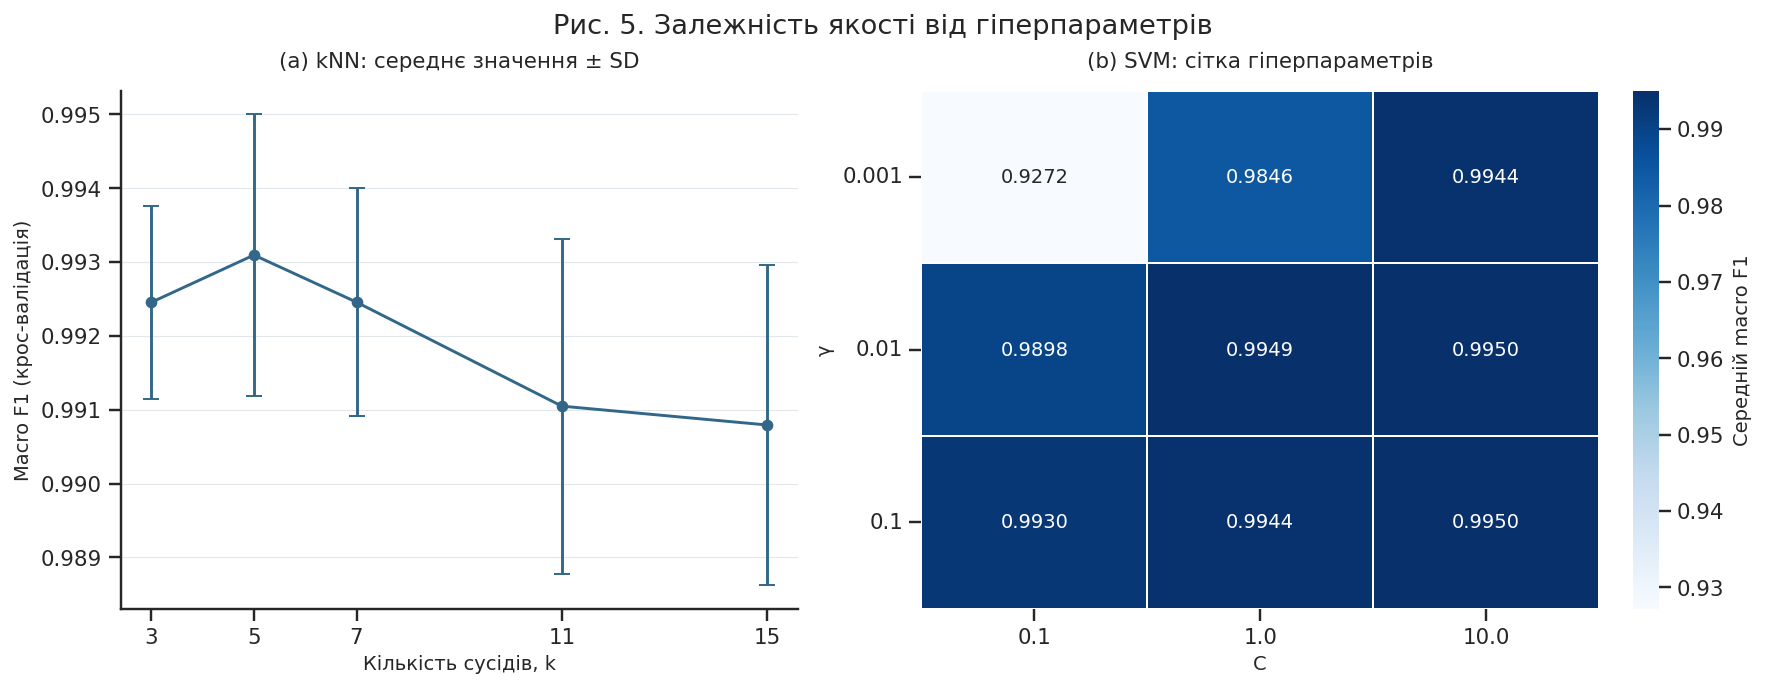

In [86]:
knn_cv = pd.DataFrame(knn_search.cv_results_)
svm_cv = pd.DataFrame(svm_search.cv_results_)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), layout="constrained")
axes[0].errorbar(knn_cv["param_model__n_neighbors"].astype(int),
                 knn_cv["mean_test_score"], yerr=knn_cv["std_test_score"],
                 marker="o", markersize=5, capsize=4, linewidth=1.5, color="#326789")
axes[0].set(title="(a) kNN: середнє значення ± SD", xlabel="Кількість сусідів, k", ylabel="Macro F1 (крос-валідація)")
axes[0].set_xticks(knn_cv["param_model__n_neighbors"].astype(int))
axes[0].yaxis.grid(True)
svm_grid = svm_cv.pivot(index="param_model__gamma", columns="param_model__C", values="mean_test_score")
sns.heatmap(svm_grid, annot=True, fmt=".4f", cmap="Blues", linewidths=0.8,
            cbar_kws={"label": "Середній macro F1"}, ax=axes[1])
axes[1].set(title="(b) SVM: сітка гіперпараметрів", xlabel="C", ylabel="γ")
axes[1].tick_params(axis="y", rotation=0)
fig.suptitle("Рис. 5. Залежність якості від гіперпараметрів", fontsize=14)
plt.show()

Параметри обрано за максимальним середнім macro F1 серед досліджених комбінацій. Вертикальні відрізки на графіку kNN позначають стандартне відхилення між фолдами (SD). Малі відмінності оцінок не свідчать про статистично підтверджену перевагу параметрів.

In [87]:
models = {"kNN": knn_search.best_estimator_, "SVM": svm_search.best_estimator_}
tree_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=1),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=RANDOM_STATE)
}
for name, classifier in tree_models.items():
    models[name] = Pipeline([("preprocessor", clone(tree_preprocessor)), ("model", classifier)])
    models[name].fit(X_train, y_train)

## 6. Оцінювання та порівняння моделей

Оцінювання виконано на спільній тестовій вибірці. **Precision** характеризує частку коректних передбачень серед віднесених до класу об’єктів; **recall** — частку виявлених об’єктів класу; **F1** — гармонійне середнє precision та recall. **Support** визначає кількість спостережень класу. Macro F1 надає класам однакову вагу, weighted F1 враховує їхній обсяг.

In [88]:
results = []
predictions = {}
reports = {}
for name, model in models.items():
    pred = model.predict(X_test)
    predictions[name] = pred
    report = classification_report(y_test, pred, labels=[0, 1], target_names=class_names,
                                   output_dict=True, zero_division=0)
    reports[name] = report
    report_table = pd.DataFrame({key: report[key] for key in class_names + ["macro avg", "weighted avg"]}).T
    show_table(report_table.reset_index().rename(columns={"index": "Клас / усереднення"}),
               f"Таблиця 9.{len(reports)}. Classification report: {name}")
    results.append({"Модель": name, "Accuracy": accuracy_score(y_test, pred),
                    "Macro F1": f1_score(y_test, pred, average="macro"),
                    "Weighted F1": f1_score(y_test, pred, average="weighted"),
                    "Recall фішингу": report[class_names[0]]["recall"],
                    "Помилок": int((pred != y_test).sum())})
comparison = pd.DataFrame(results).sort_values(["Macro F1", "Accuracy"], ascending=False).reset_index(drop=True)
show_table(comparison, "Таблиця 10. Порівняння моделей на тестовій вибірці")

Таблиця 9.1. Classification report: kNN


,Клас / усереднення,precision,recall,f1-score,support
0,Фішинг,1.0000,0.9941,0.9971,854.0
1,Легітимний,0.9957,1.0000,0.9978,1146.0
2,macro avg,0.9978,0.9971,0.9974,2000.0
3,weighted avg,0.9975,0.9975,0.9975,2000.0


Таблиця 9.2. Classification report: SVM


,Клас / усереднення,precision,recall,f1-score,support
0,Фішинг,1.0000,0.9965,0.9982,854.0
1,Легітимний,0.9974,1.0000,0.9987,1146.0
2,macro avg,0.9987,0.9982,0.9985,2000.0
3,weighted avg,0.9985,0.9985,0.9985,2000.0


Таблиця 9.3. Classification report: Decision Tree


...

,Клас / усереднення,precision,recall,f1-score,support
0,Фішинг,0.9965,0.9941,0.9953,854.0
1,Легітимний,0.9956,0.9974,0.9965,1146.0
2,macro avg,0.9961,0.9958,0.9959,2000.0
3,weighted avg,0.9960,0.9960,0.9960,2000.0


Таблиця 9.5. Classification report: AdaBoost


,Клас / усереднення,precision,recall,f1-score,support
0,Фішинг,0.9988,0.9614,0.9797,854.0
1,Легітимний,0.9720,0.9991,0.9854,1146.0
2,macro avg,0.9854,0.9802,0.9825,2000.0
3,weighted avg,0.9834,0.9830,0.9830,2000.0


Таблиця 10. Порівняння моделей на тестовій вибірці


,Модель,Accuracy,Macro F1,Weighted F1,Recall фішингу,Помилок
0,SVM,0.9985,0.9985,0.9985,0.9965,3
1,kNN,0.9975,0.9974,0.9975,0.9941,5
2,Random Forest,0.9960,0.9959,0.9960,0.9941,8
3,Decision Tree,0.9920,0.9918,0.9920,0.9930,16
4,AdaBoost,0.9830,0.9825,0.9830,0.9614,34


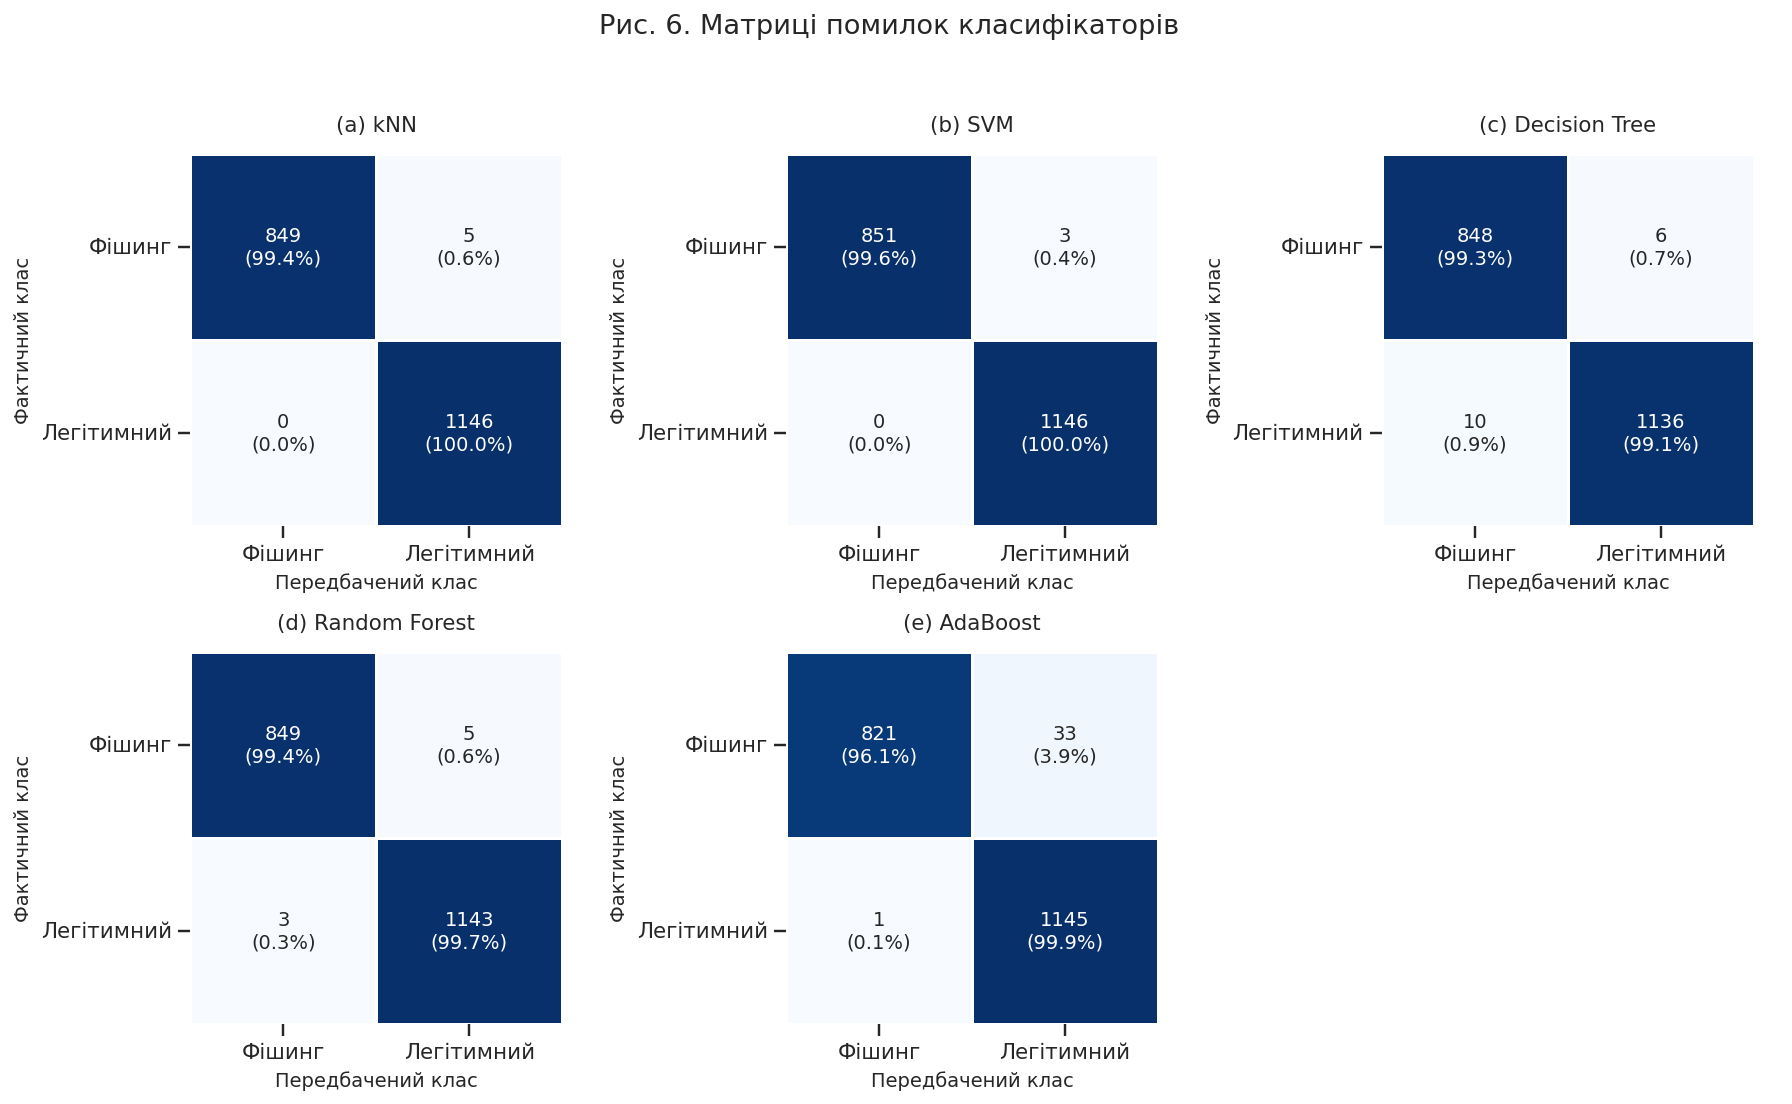

In [89]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for index, ((name, pred), ax) in enumerate(zip(predictions.items(), axes.flat)):
    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    proportions = cm / cm.sum(axis=1, keepdims=True)
    annotations = np.array([[f"{cm[i, j]}\n({proportions[i, j]:.1%})" for j in range(2)] for i in range(2)])
    sns.heatmap(proportions, annot=annotations, fmt="", cmap="Blues", cbar=False,
                vmin=0, vmax=1, square=True, linewidths=1.5, annot_kws={"fontsize": 10},
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set(title=f"({chr(97 + index)}) {name}", xlabel="Передбачений клас", ylabel="Фактичний клас")
    ax.tick_params(axis="both", rotation=0)
axes.flat[-1].axis("off")
fig.suptitle("Рис. 6. Матриці помилок класифікаторів", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

Діагональні клітинки відповідають правильним передбаченням. Верхня права клітинка відображає пропущений фішинг, нижня ліва — легітимні URL, помилково визначені як фішингові. Відсотки нормовано за фактичним класом; спільна колірна шкала забезпечує порівнянність панелей.

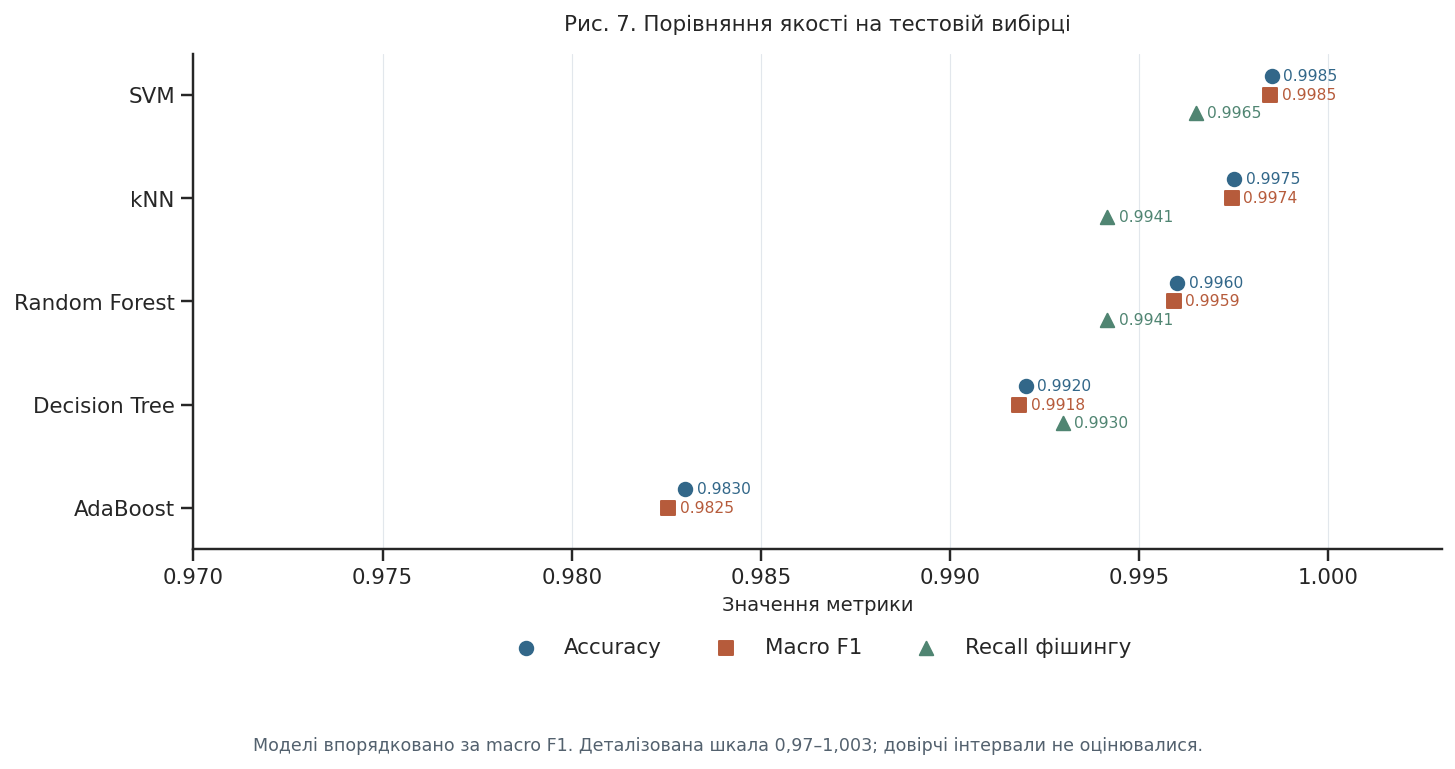

In [90]:
metric_colors = ["#326789", "#b65b3b", "#508572"]
markers = ["o", "s", "^"]
metrics = ["Accuracy", "Macro F1", "Recall фішингу"]
fig, ax = plt.subplots(figsize=(10.5, 5.5))
positions = np.arange(len(comparison))
for offset, metric, color, marker in zip([-0.18, 0, 0.18], metrics, metric_colors, markers):
    values = comparison[metric].to_numpy()
    ax.scatter(values, positions + offset, color=color, marker=marker, s=48, label=metric, zorder=3)
    for value, position in zip(values, positions + offset):
        ax.annotate(f"{value:.4f}", (value, position), xytext=(6, 0), textcoords="offset points", va="center", fontsize=8, color=color)
ax.set_yticks(positions, comparison["Модель"])
ax.invert_yaxis()
ax.set(xlim=(0.97, 1.003), xlabel="Значення метрики", title="Рис. 7. Порівняння якості на тестовій вибірці")
ax.set_xticks(np.arange(0.97, 1.001, 0.005))
ax.xaxis.grid(True)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3)
fig.text(0.5, 0.015, "Моделі впорядковано за macro F1. Деталізована шкала 0,97–1,003; довірчі інтервали не оцінювалися.", ha="center", fontsize=9, color="#53616e")
fig.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

## Висновки

Найвище значення macro F1 отримано для **Random Forest (0,9964)**; результат **SVM** є практично рівноцінним. Обидві моделі забезпечили accuracy **99,65%** і допустили по **7 помилок із 2000 спостережень**. Random Forest пропустив 3 фішингові URL, SVM — 4. Різниця macro F1 менша за 0,00001, тому стійку перевагу однієї моделі не встановлено.

Результат Random Forest узгоджується зі здатністю ансамблю дерев моделювати нелінійні взаємодії ознак. Проте це пояснення не перевірено окремим експериментом. Для задачі виявлення фішингу суттєвим є recall класу 0, оскільки його зниження відповідає збільшенню кількості пропущених небезпечних адрес.

Гіперпараметри обрано за крос-валідацією навчальних даних. Порівняння моделей є описовим і ґрунтується на одному тестовому розподілі підвибірки. Для підтвердження узагальнюваності необхідне оцінювання на незалежних доменах або даних іншого періоду.